In [5]:
import numpy as np
import h5py
import os
import time

from matplotlib import pyplot as plt
from simulation import run_simulation, run_tdi
from qtransform import generate_qscan
from h5file_helpers import create_dataset, append_gw_sample
from config import *


In [6]:
pipe = {'t0':10368000, 'dt':0.25, 'size':72000, 'gw_beta':0, 'gw_lambda':np.pi/7}

glitches = [{'type':'OneSidedDoubleExpGlitch', 't_inj': 0,
             'level':0, 't_rise':1, 't_fall':1, 'inj_point':'readout_tmi_carrier_12'}]

In [7]:
H, W = 512, 512
if os.path.exists(gw_dataset_path):
    os.remove(gw_dataset_path)
    
h5file = create_dataset(gw_dataset_path, resolution=(H, W))


In [8]:
mass_arr = [1e5]
q_arr = [1, 10]

start = time.time()
for m in mass_arr:
    for q in q_arr:

        gws = [{'type':'BinaryInspiralGW', 'm1':m, 'm2':m*q, 'd':1e4, 
        'e':0.0, 't_inj':2.5*3600, 'domain':'freq'}]

        run_simulation(gws, glitches, pipe,
                    gw_path, glitch_path, orbits_path, simulation_path, disable_noise=False,)
        tdi_dict = run_tdi(simulation_path, pipe)

        event = gws[0]
        t_arr, f_arr, QT = generate_qscan(tdi_dict, Q=15, channel='X', pipe=pipe, event=event, resolution=512, 
                        frange=(1e-3, 1e-1), trange=(-1, 1))
        append_gw_sample(h5file, QT, event['m1'], event['m2'], event['d'])
end = time.time()
print(f"Total time taken: {end - start} seconds")

You are using an orbit file in a version that might not be fully supported


You are using an orbit file in a version that might not be fully supported
You are using a glitch file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported
You are using a glitch file in a version that might not be fully supported


Total time taken: 16.170066118240356 seconds


In [10]:
with h5py.File(gw_dataset_path, "r") as h5:
    QT_array = h5["QT"][:]       # shape (N, 512, 512)
    m1_array = h5["m1"][:]
    m2_array = h5["m2"][:]
    d_array = h5["d"][:]

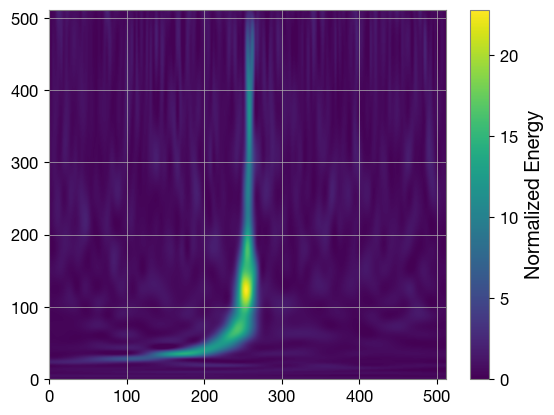

In [11]:
plt.imshow(QT_array[0], origin='lower', aspect='auto')
plt.colorbar(label='Normalized Energy')
#plt.yscale('log')

In [12]:
QT_array.shape

(2, 512, 512)